Unnamed: 0: Otomatik oluşturulmuş sıra numarası.

district: Evin bulunduğu ilçe.

price: Evin satış fiyatı.

address: İlanın bağlantı yolu (navigasyon adresi).

AdUpdateDate: İlanın güncellenme tarihi.

Category: İlan türü (örneğin "Satılık").

GrossSquareMeters: Brüt metrekare alanı.

BuildingAge: Binanın yaşı.

NumberFloorsofBuilding: Binadaki toplam kat sayısı.

UsingStatus: Evin kullanım durumu (örneğin "Mülk Sahibi Oturuyor").

EligibilityForInvestment: Yatırıma uygunluk bilgisi.

BuildStatus: Yapı durumu (örneğin "İnşaat halinde").

TitleStatus: Tapu durumu.

ItemStatus: Eşya durumu (eşyalı/eşyasız).

NumberOfBathrooms: Banyo sayısı.

NumberOfWCs: WC sayısı.

AdCreationDate: İlanın oluşturulma tarihi.

Type: Evin tipi (örneğin daire, villa).

NetSquareMeters: Net metrekare alanı.

NumberOfRooms: Oda sayısı (örneğin 2+1).

FloorLocation: Evin bulunduğu kat.

HeatingType: Isıtma tipi (örneğin kombi, merkezi).

CreditEligibility: Krediye uygunluk durumu.

InsideTheSite: Site içinde olup olmadığı.

StructureType: Yapı tipi (örneğin betonarme).

MortgageStatus: İpotek durumu.

Swap: Takasa uygunluk.

Balcony: Balkon olup olmadığı.

PriceStatus: Fiyat tipi (örneğin sabit).

RentalIncome: Kira getirisi.

NumberOfBalconies: Balkon sayısı.

BalconyType: Balkon tipi.

HallSquareMeters: Salon metrekare alanı.

WCSquareMeters: WC alanı.

IsItVideoNavigable?: Video ile gezilebilirlik.

Subscription: Abonelik durumu (doğalgaz, su vb.).

BathroomSquareMeters: Banyo alanı.

BalconySquareMeters: Balkon alanı.


In [487]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [488]:
import pandas as pd

# Veri setini yükleme
df = pd.read_csv('/content/drive/MyDrive/KNN-karar-ağaçları/KNN-KARAR AG╠åAC╠ğLARI/HouseData.csv')






In [489]:
# İlk 5 satırı görüntüle
df.head(20)

,Unnamed: 0,district,price,address,AdUpdateDate,Category,GrossSquareMeters,BuildingAge,NumberFloorsofBuilding,UsingStatus,...,PriceStatus,RentalIncome,NumberOfBalconies,BalconyType,HallSquareMeters,WCSquareMeters,IsItVideoNavigable?,Subscription,BathroomSquareMeters,BalconySquareMeters
0,0,adalar,"3,100,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",24 Şubat 2022,Satılık,160 m2,21 Ve Üzeri,3,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,adalar,"1,600,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",02 Mart 2022,Satılık,120 m2,5-10,3,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,adalar,"18,500,000TL","['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",11 Şubat 2022,Satılık,350 m2,21 Ve Üzeri,2,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,adalar,"9,500,000TL","['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...",11 Şubat 2022,Satılık,550 m2,11-15,3,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,adalar,"25,000,000TL","['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",19 Ocak 2022,Satılık,840 m2,21 Ve Üzeri,4,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,adalar,"7,000,000TL","['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",17 Ocak 2022,Satılık,200 m2,21 Ve Üzeri,2,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,adalar,"3,250,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",27 Şubat 2022,Satılık,400 m2,21 Ve Üzeri,3,Kiracı Oturuyor,...,Genel Fiyat,12.000 TL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,adalar,"2,850,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",22 Şubat 2022,Satılık,250 m2,21 Ve Üzeri,2,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,adalar,"8,350,000TL","['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",16 Aralık 2021,Satılık,360 m2,21 Ve Üzeri,2,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,adalar,"10,800,000TL","['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",16 Aralık 2021,Satılık,180 m2,21 Ve Üzeri,2,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [490]:
df.tail(10)

,Unnamed: 0,district,price,address,AdUpdateDate,Category,GrossSquareMeters,BuildingAge,NumberFloorsofBuilding,UsingStatus,...,PriceStatus,RentalIncome,NumberOfBalconies,BalconyType,HallSquareMeters,WCSquareMeters,IsItVideoNavigable?,Subscription,BathroomSquareMeters,BalconySquareMeters
25145,25145,zeytinburnu,"12,000,000TLarrow_downward%25","['Anasayfa', 'Satılık Residence', 'İstanbul Sa...",28 Şubat 2022,Satılık,246 m2,5-10,30,Boş,...,Genel Fiyat,20.000 TL,NaN,NaN,NaN,NaN,NaN,2.215 TL,NaN,NaN
25146,25146,zeytinburnu,"5,150,000TL","['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...",25 Ekim 2021,Satılık,401 m2,1,4,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25147,25147,zeytinburnu,"6,000,000TL","['Anasayfa', 'Satılık Residence', 'İstanbul Sa...",28 Şubat 2022,Satılık,121 m2,5-10,30,Kiracı Oturuyor,...,Genel Fiyat,10.000 TL,NaN,NaN,NaN,NaN,NaN,1.090 TL,NaN,NaN
25148,25148,zeytinburnu,"22,000,000TL","['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",28 Şubat 2022,Satılık,340 m2,2,3,Kiracı Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25149,25149,zeytinburnu,"2,950,000TL","['Anasayfa', 'Satılık Residence', 'İstanbul Sa...",12 Ocak 2022,Satılık,70 m2,0 (Yeni),12,Kiracı Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25150,25150,zeytinburnu,"1,850,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",12 Ocak 2022,Satılık,180 m2,5-10,4,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25151,25151,zeytinburnu,"1,100,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",10 Aralık 2021,Satılık,52 m2,3,16,Kiracı Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25152,25152,zeytinburnu,"9,000,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",26 Şubat 2022,Satılık,176 m2,0 (Yeni),25,Boş,...,Genel Fiyat,NaN,NaN,NaN,55 m2,NaN,NaN,NaN,NaN,NaN
25153,25153,zeytinburnu,"13,000,000TL","['Anasayfa', 'Satılık Residence', 'İstanbul Sa...",18 Ekim 2021,Satılık,170 m2,5-10,30,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25154,25154,zeytinburnu,"1,000,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",10 Aralık 2021,Satılık,55 m2,0 (Yeni),16,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [491]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25155 entries, 0 to 25154
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                25155 non-null  int64 
 1   district                  25155 non-null  object
 2   price                     25155 non-null  object
 3   address                   25155 non-null  object
 4   AdUpdateDate              25155 non-null  object
 5   Category                  25155 non-null  object
 6   GrossSquareMeters         25155 non-null  object
 7   BuildingAge               25155 non-null  object
 8   NumberFloorsofBuilding    25155 non-null  int64 
 9   UsingStatus               25155 non-null  object
 10  EligibilityForInvestment  21506 non-null  object
 11  BuildStatus               11231 non-null  object
 12  TitleStatus               9712 non-null   object
 13  ItemStatus                18332 non-null  object
 14  NumberOfBathrooms     

0 sütunu ne kaldırılmalı

In [492]:
df.columns

Index(['Unnamed: 0', 'district', 'price', 'address', 'AdUpdateDate',
       'Category', 'GrossSquareMeters', 'BuildingAge',
       'NumberFloorsofBuilding', 'UsingStatus', 'EligibilityForInvestment',
       'BuildStatus', 'TitleStatus', 'ItemStatus', 'NumberOfBathrooms',
       'NumberOfWCs', 'AdCreationDate', 'Type', 'NetSquareMeters',
       'NumberOfRooms', 'FloorLocation', 'HeatingType', 'CreditEligibility',
       'InsideTheSite', 'StructureType', 'MortgageStatus', 'Swap', 'Balcony',
       'PriceStatus', 'RentalIncome', 'NumberOfBalconies', 'BalconyType',
       'HallSquareMeters', 'WCSquareMeters', 'IsItVideoNavigable?',
       'Subscription', 'BathroomSquareMeters', 'BalconySquareMeters'],
      dtype='object')

In [493]:
display(df.isnull().sum())

,0
Unnamed: 0,0
district,0
price,0
address,0
AdUpdateDate,0
Category,0
GrossSquareMeters,0
BuildingAge,0
NumberFloorsofBuilding,0
UsingStatus,0


In [494]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


# Sayısal hale dönüştürülmesi gereken sütunlar
numeric_columns = [
    'price', 'GrossSquareMeters', 'NetSquareMeters',
    'NumberOfBathrooms', 'NumberOfRooms', 'NumberOfWCs',
    'FloorLocation', 'NumberOfBalconies', 'HallSquareMeters',
    'BathroomSquareMeters', 'BalconySquareMeters', 'WCSquareMeters',
    'RentalIncome','BuildingAge','NetSquareMeters','Subscription'
]

# Sayısal dönüşüm: Sütunları temizleyerek dönüştürme
for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].replace(r'[^\d.]', '', regex=True)  # Sayısal olmayan karakterleri kaldır
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Sayıya dönüştür

        # Temizlenen fiyat ve metrekare değerlerini kontrol et
print(df[['price','GrossSquareMeters','BuildingAge','NetSquareMeters','NumberOfBathrooms']].head())


      price  GrossSquareMeters  BuildingAge  NetSquareMeters  \
0   3100000             1602.0           21           1202.0   
1   1600000             1202.0          510           1002.0   
2  18500000             3502.0           21           3002.0   
3   9500000             5502.0         1115           5402.0   
4  25000000             8402.0           21           7002.0   

   NumberOfBathrooms  
0                2.0  
1                1.0  
2                3.0  
3                4.0  
4                3.0  


price gibi değerlerin sonunda TL yazdığı için sayısala dönüştürmemiz gerekti. regexle bazı şeyleri sildik

In [495]:
# Eksik değerlerin oranını hesapla
missing_data_summary = df.isnull().sum().sort_values(ascending=False).to_frame(name='MissingCount')
missing_data_summary['MissingPercentage'] = (missing_data_summary['MissingCount'] / len(df)) * 100
print(missing_data_summary)

                          MissingCount  MissingPercentage
WCSquareMeters                   24290          96.561320
BalconySquareMeters              24115          95.865633
BathroomSquareMeters             24043          95.579408
HallSquareMeters                 23722          94.303319
Subscription                     20670          82.170543
BalconyType                      20435          81.236335
NumberOfBalconies                19831          78.835222
IsItVideoNavigable?              19674          78.211091
RentalIncome                     19351          76.927052
MortgageStatus                   19097          75.917313
NumberOfWCs                      17182          68.304512
Balcony                          16046          63.788511
TitleStatus                      15443          61.391373
StructureType                    14749          58.632479
BuildStatus                      13924          55.352813
FloorLocation                     7308          29.051878
ItemStatus    

In [496]:
# Eksik değer oranlarını hesapla
missing_summary = df.isnull().sum().sort_values(ascending=False).to_frame(name='MissingCount')
missing_summary['MissingPercentage'] = (missing_summary['MissingCount'] / len(df)) * 100

# %64'ten fazla eksik değeri olan sütunları bul
columns_to_drop = missing_summary[missing_summary['MissingPercentage'] > 66].index.tolist()


# Bu sütunları veri setinden çıkar
df = df.drop(columns=columns_to_drop)

#gereksiz sütunları da çıkaralım
df = df.drop(columns=['Unnamed: 0','address','AdUpdateDate','Category','AdUpdateDate','AdCreationDate','AdUpdateDate','Type'], errors='ignore')

# Kontrol için kalan sütunları yazdır
print("Kalan sütunlar:\n", df.columns.tolist())

Kalan sütunlar:
 ['district', 'price', 'GrossSquareMeters', 'BuildingAge', 'NumberFloorsofBuilding', 'UsingStatus', 'EligibilityForInvestment', 'BuildStatus', 'TitleStatus', 'ItemStatus', 'NumberOfBathrooms', 'NetSquareMeters', 'NumberOfRooms', 'FloorLocation', 'HeatingType', 'CreditEligibility', 'InsideTheSite', 'StructureType', 'Swap', 'Balcony', 'PriceStatus']


 %67
 üstü eksik sütunlar ve modelde gereksizolan adres gibi sütunlar silindi

In [497]:
# Eksik değerlerin oranını hesapla
missing_data_summary = df.isnull().sum().sort_values(ascending=False).to_frame(name='MissingCount')
missing_data_summary['MissingPercentage'] = (missing_data_summary['MissingCount'] / len(df)) * 100
print(missing_data_summary)

                          MissingCount  MissingPercentage
Balcony                          16046          63.788511
TitleStatus                      15443          61.391373
StructureType                    14749          58.632479
BuildStatus                      13924          55.352813
FloorLocation                     7308          29.051878
ItemStatus                        6823          27.123832
Swap                              4316          17.157623
EligibilityForInvestment          3649          14.506062
NumberOfRooms                      263           1.045518
NumberOfBathrooms                  250           0.993838
district                             0           0.000000
GrossSquareMeters                    0           0.000000
price                                0           0.000000
NumberFloorsofBuilding               0           0.000000
BuildingAge                          0           0.000000
NetSquareMeters                      0           0.000000
UsingStatus   

In [498]:
# 'Balcony' sütununda gerçekten "NaN" yazan metin değerlerini kontrol edelim
balcony_none_values = df['Balcony'].value_counts(dropna=False)

balcony_none_values


,count
Balcony,
NaN,16046
Var,7695
Yok,1414


balkonda NAN yazan değerler var onlar büyük ihtimalle balkonnun olmadığını gösteriyor o yüzden nan lar yok a dönüştürüldü

In [499]:
df['Balcony'] = df['Balcony'].fillna('Yok')


bazı veriler bilinmiyor olarak işaretlendi

In [500]:
df['StructureType'] = df['StructureType'].fillna('Bilinmiyor')

In [501]:
df['BuildStatus'] = df['BuildStatus'].fillna('Bilinmiyor')

In [502]:
# Eksik değerlerin oranını hesapla
missing_data_summary = df.isnull().sum().sort_values(ascending=False).to_frame(name='MissingCount')
missing_data_summary['MissingPercentage'] = (missing_data_summary['MissingCount'] / len(df)) * 100
print(missing_data_summary)

                          MissingCount  MissingPercentage
TitleStatus                      15443          61.391373
FloorLocation                     7308          29.051878
ItemStatus                        6823          27.123832
Swap                              4316          17.157623
EligibilityForInvestment          3649          14.506062
NumberOfRooms                      263           1.045518
NumberOfBathrooms                  250           0.993838
NumberFloorsofBuilding               0           0.000000
price                                0           0.000000
district                             0           0.000000
BuildingAge                          0           0.000000
GrossSquareMeters                    0           0.000000
UsingStatus                          0           0.000000
NetSquareMeters                      0           0.000000
BuildStatus                          0           0.000000
CreditEligibility                    0           0.000000
HeatingType   

seçilen sütunları sayısal ve kategorik olarak ayırır. ona göre mod veya medyanını alıp doldurur.

In [503]:

columns_to_fill = ['TitleStatus','ItemStatus', 'Swap', 'EligibilityForInvestment','FloorLocation','NumberOfRooms','NumberOfBathrooms']
existing_columns_to_fill = [col for col in columns_to_fill if col in df.columns]


for col in existing_columns_to_fill:
    if df[col].dtype == 'object':  # Kategorik sütunlar
        df[col] = df[col].fillna(df[col].mode()[0])
    else:  # Sayısal sütunlar
        df[col] = df[col].fillna(df[col].median())


In [504]:
# Eksik değerlerin oranını hesapla
missing_data_summary = df.isnull().sum().sort_values(ascending=False).to_frame(name='MissingCount')
missing_data_summary['MissingPercentage'] = (missing_data_summary['MissingCount'] / len(df)) * 100
print(missing_data_summary)

                          MissingCount  MissingPercentage
district                             0                0.0
price                                0                0.0
GrossSquareMeters                    0                0.0
BuildingAge                          0                0.0
NumberFloorsofBuilding               0                0.0
UsingStatus                          0                0.0
EligibilityForInvestment             0                0.0
BuildStatus                          0                0.0
TitleStatus                          0                0.0
ItemStatus                           0                0.0
NumberOfBathrooms                    0                0.0
NetSquareMeters                      0                0.0
NumberOfRooms                        0                0.0
FloorLocation                        0                0.0
HeatingType                          0                0.0
CreditEligibility                    0                0.0
InsideTheSite 

In [505]:
df.tail()

,district,price,GrossSquareMeters,BuildingAge,NumberFloorsofBuilding,UsingStatus,EligibilityForInvestment,BuildStatus,TitleStatus,ItemStatus,...,NetSquareMeters,NumberOfRooms,FloorLocation,HeatingType,CreditEligibility,InsideTheSite,StructureType,Swap,Balcony,PriceStatus
25150,zeytinburnu,1850000,1802.0,510,4,Mülk Sahibi Oturuyor,Yatırıma Uygun,İkinci El,Kat Mülkiyeti,Boş,...,1602.0,41.0,4.0,Kombi Doğalgaz,Krediye Uygun,Hayır,Betonarme,Yok,Yok,Genel Fiyat
25151,zeytinburnu,1100000,522.0,3,16,Kiracı Oturuyor,Yatırıma Uygun,İkinci El,Kat Mülkiyeti,Boş,...,352.0,11.0,3.0,Merkezi (Pay Ölçer),Krediye Uygun,Hayır,Betonarme,Yok,Yok,Genel Fiyat
25152,zeytinburnu,9000000,1762.0,0,25,Boş,Yatırıma Uygun,Sıfır,Kat Mülkiyeti,Boş,...,1752.0,31.0,17.0,Jeotermal,Krediye Uygun,Hayır,Betonarme,Yok,Yok,Genel Fiyat
25153,zeytinburnu,13000000,1702.0,510,30,Boş,Bilinmiyor,İkinci El,Kat Mülkiyeti,Boş,...,1552.0,31.0,20.0,Merkezi Doğalgaz,Krediye Uygun,Hayır,Betonarme,Yok,Yok,Genel Fiyat
25154,zeytinburnu,1000000,552.0,0,16,Boş,Yatırıma Uygun,Sıfır,Kat Mülkiyeti,Boş,...,482.0,11.0,3.0,Merkezi (Pay Ölçer),Krediye Uygun,Hayır,Betonarme,Yok,Yok,Genel Fiyat


In [506]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25155 entries, 0 to 25154
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   district                  25155 non-null  object 
 1   price                     25155 non-null  int64  
 2   GrossSquareMeters         25155 non-null  float64
 3   BuildingAge               25155 non-null  int64  
 4   NumberFloorsofBuilding    25155 non-null  int64  
 5   UsingStatus               25155 non-null  object 
 6   EligibilityForInvestment  25155 non-null  object 
 7   BuildStatus               25155 non-null  object 
 8   TitleStatus               25155 non-null  object 
 9   ItemStatus                25155 non-null  object 
 10  NumberOfBathrooms         25155 non-null  float64
 11  NetSquareMeters           25155 non-null  float64
 12  NumberOfRooms             25155 non-null  float64
 13  FloorLocation             25155 non-null  float64
 14  Heatin

In [507]:
df.head()


,district,price,GrossSquareMeters,BuildingAge,NumberFloorsofBuilding,UsingStatus,EligibilityForInvestment,BuildStatus,TitleStatus,ItemStatus,...,NetSquareMeters,NumberOfRooms,FloorLocation,HeatingType,CreditEligibility,InsideTheSite,StructureType,Swap,Balcony,PriceStatus
0,adalar,3100000,1602.0,21,3,Mülk Sahibi Oturuyor,Bilinmiyor,Bilinmiyor,Kat Mülkiyeti,Eşyalı,...,1202.0,31.0,4.0,Kombi Doğalgaz,Krediye Uygun,Hayır,Bilinmiyor,Yok,Yok,Genel Fiyat
1,adalar,1600000,1202.0,510,3,Mülk Sahibi Oturuyor,Yatırıma Uygun,İkinci El,Kat Mülkiyeti,Eşyalı,...,1002.0,21.0,4.0,Kombi Doğalgaz,Krediye Uygun,Hayır,Betonarme,Yok,Var,Genel Fiyat
2,adalar,18500000,3502.0,21,2,Mülk Sahibi Oturuyor,Bilinmiyor,Bilinmiyor,Kat Mülkiyeti,Boş,...,3002.0,31.0,4.0,Kombi Doğalgaz,Krediye Uygun,Hayır,Bilinmiyor,Yok,Yok,Genel Fiyat
3,adalar,9500000,5502.0,1115,3,Mülk Sahibi Oturuyor,Bilinmiyor,İkinci El,Kat Mülkiyeti,Boş,...,5402.0,8.0,4.0,Kombi Doğalgaz,Krediye Uygun Değil,Hayır,Betonarme,Yok,Yok,Genel Fiyat
4,adalar,25000000,8402.0,21,4,Boş,Bilinmiyor,İkinci El,Kat Mülkiyeti,Boş,...,7002.0,8.0,4.0,Isıtma Yok,Krediye Uygun,Hayır,Ahşap,Yok,Yok,Genel Fiyat


In [508]:
# Kategorik sütunları belirleme
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Her kategorik sütunun unique değerlerini yazdırma
for col in categorical_columns:
    unique_values = df[col].unique()
    print(f"Sütun: {col}")
    print(f"Unique Değerler ({len(unique_values)}): {unique_values}")
    print("-" * 50)

Sütun: district
Unique Değerler (39): ['adalar' 'arnavutkoy' 'atasehir' 'avcilar' 'bagcilar' 'bahcelievler'
 'bakirkoy' 'basaksehir' 'bayrampasa' 'besiktas' 'beykoz' 'beylikduzu'
 'beyoglu' 'buyukcekmece' 'catalca' 'cekmekoy' 'esenler' 'esenyurt'
 'eyupsultan' 'fatih' 'gaziosmanpasa' 'gungoren' 'kadikoy' 'kagithane'
 'kartal' 'kucukcekmece' 'maltepe' 'pendik' 'sancaktepe' 'sariyer' 'sile'
 'silivri' 'sisli' 'sultanbeyli' 'sultangazi' 'tuzla' 'umraniye' 'uskudar'
 'zeytinburnu']
--------------------------------------------------
Sütun: UsingStatus
Unique Değerler (3): ['Mülk Sahibi Oturuyor' 'Boş' 'Kiracı Oturuyor']
--------------------------------------------------
Sütun: EligibilityForInvestment
Unique Değerler (3): ['Bilinmiyor' 'Yatırıma Uygun' 'Yatırıma Uygun Değil']
--------------------------------------------------
Sütun: BuildStatus
Unique Değerler (4): ['Bilinmiyor' 'İkinci El' 'Sıfır' 'Yapım Aşamasında']
--------------------------------------------------
Sütun: TitleStatus
Uni

In [509]:
# Ortalama fiyatı hesapla
ortalama_fiyat = df['price'].mean()
print (ortalama_fiyat)


12870621.53802425


ortalama fiyat 12870621.53802425 aykırı değer var baya bi demekkii :O :O :O :O

aykırı değer analizi


--- price Sütunu ---


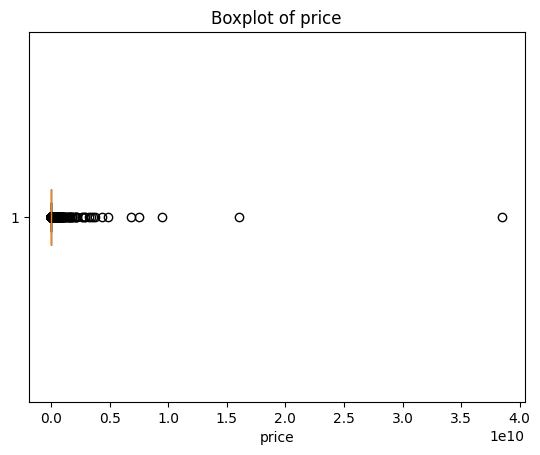

IQR: 129695002.76, Lower Bound: -194237504.14000002, Upper Bound: 324542506.90000004
Aykırı Değer Sayısı: 108
Z-Score ile Aykırı Değer Sayısı: 42


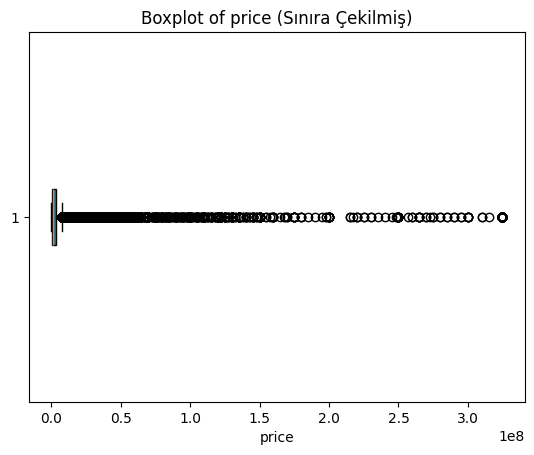


--- GrossSquareMeters Sütunu ---


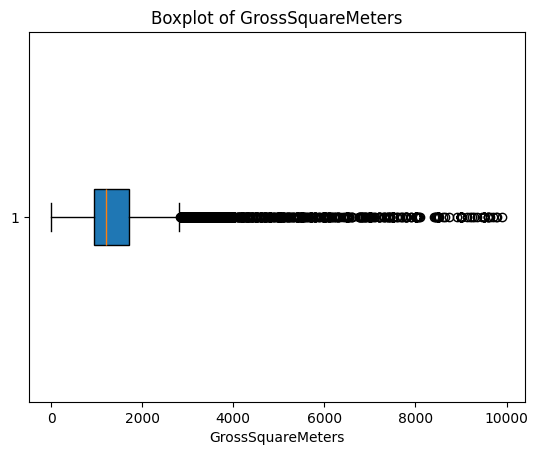

IQR: 5623.0, Lower Bound: -8055.5, Upper Bound: 14436.5
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 561


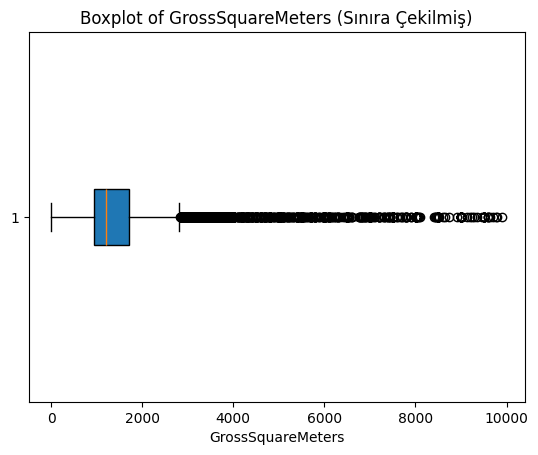


--- NetSquareMeters Sütunu ---


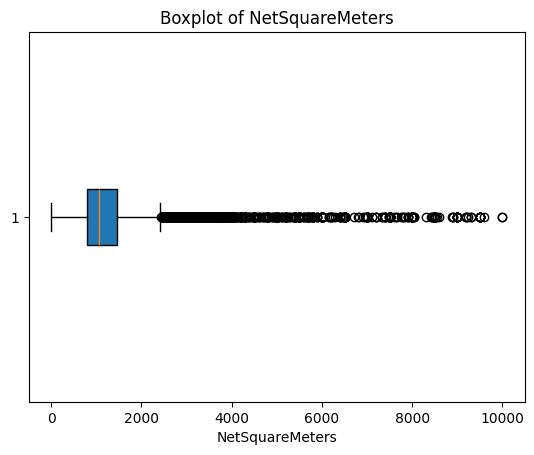

IQR: 5200.0, Lower Bound: -7498.0, Upper Bound: 13302.0
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 523


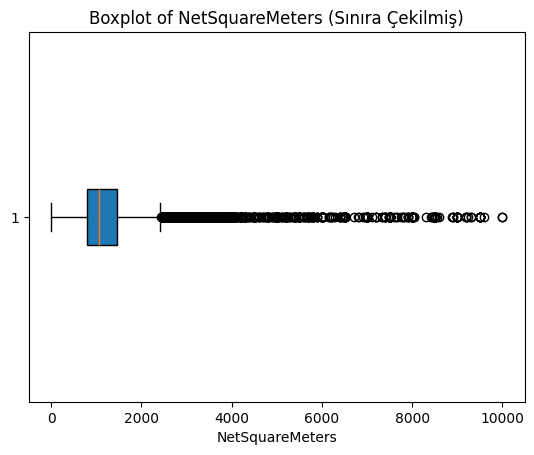


--- NumberOfBathrooms Sütunu ---


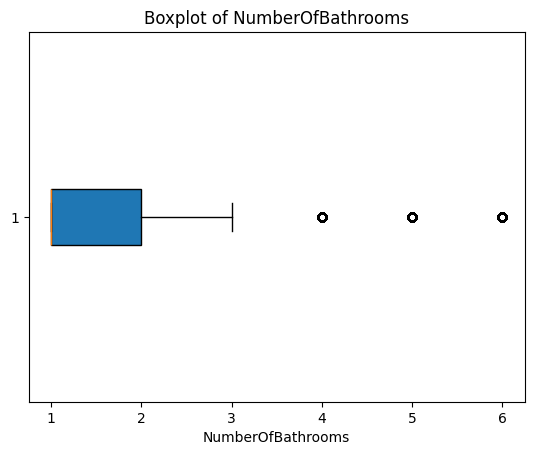

IQR: 4.0, Lower Bound: -5.0, Upper Bound: 11.0
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 448


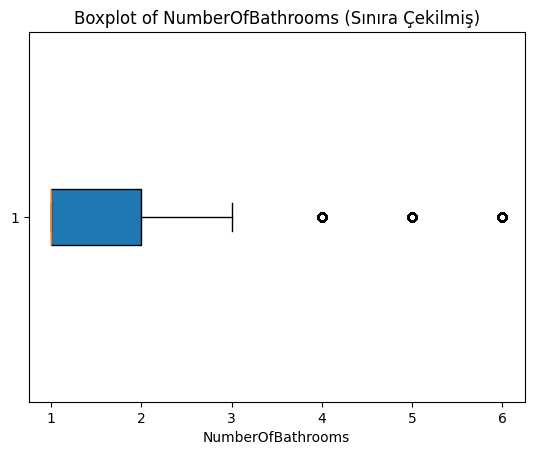


--- NumberOfRooms Sütunu ---


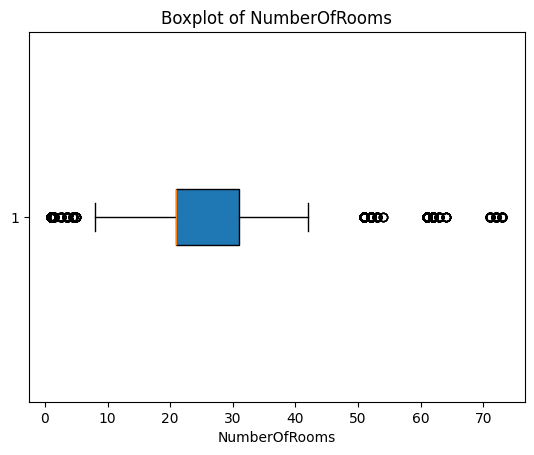

IQR: 58.49, Lower Bound: -84.225, Upper Bound: 149.735
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 165


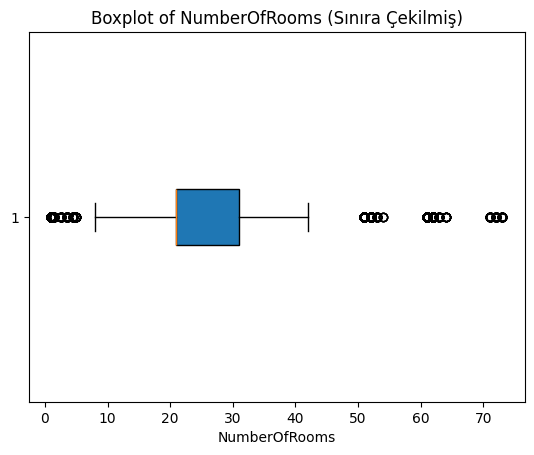


--- FloorLocation Sütunu ---


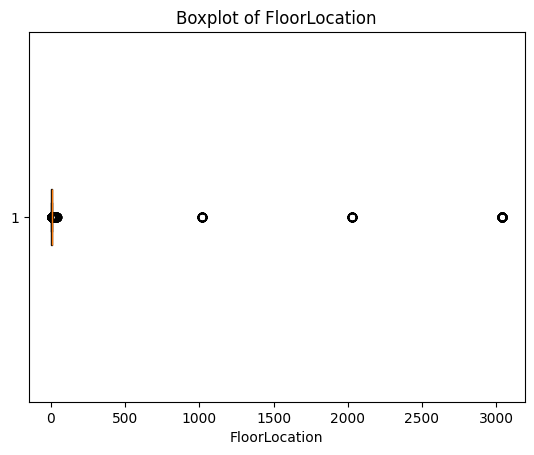

IQR: 29.0, Lower Bound: -42.5, Upper Bound: 73.5
Aykırı Değer Sayısı: 169
Z-Score ile Aykırı Değer Sayısı: 169


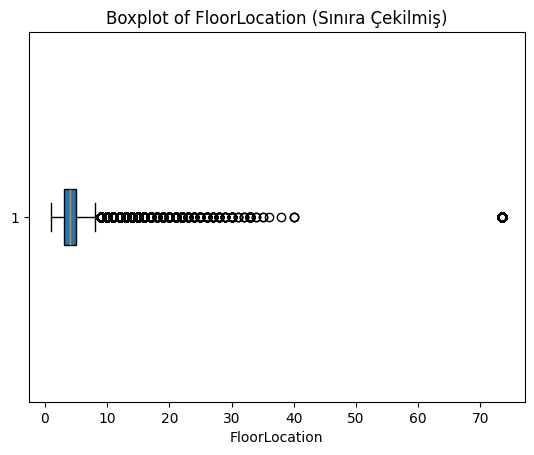


--- BuildingAge Sütunu ---


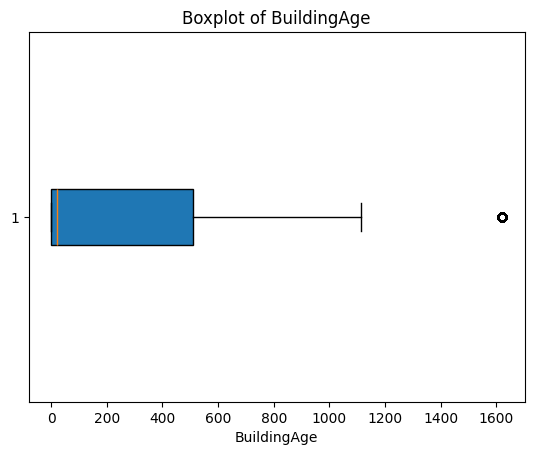

IQR: 1620.0, Lower Bound: -2430.0, Upper Bound: 4050.0
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 783


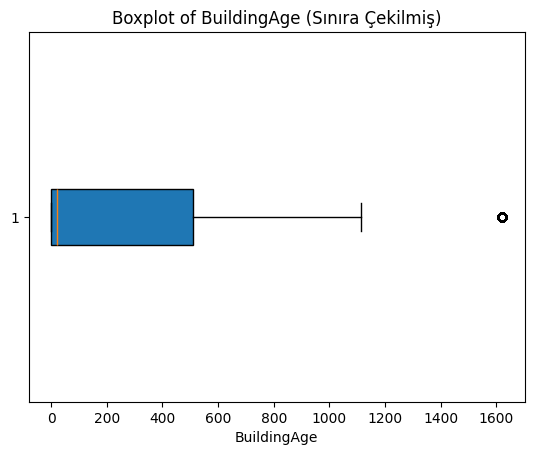


--- NetSquareMeters Sütunu ---


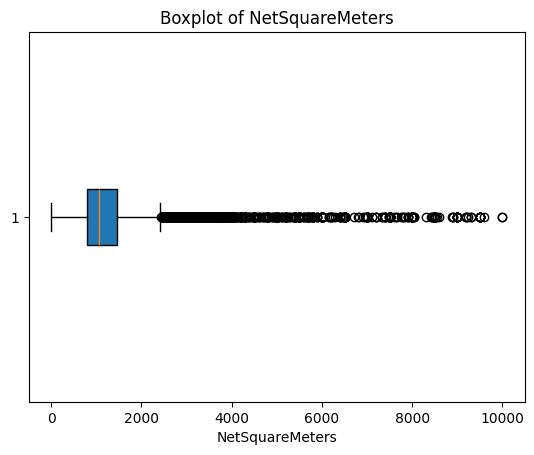

IQR: 5200.0, Lower Bound: -7498.0, Upper Bound: 13302.0
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 523


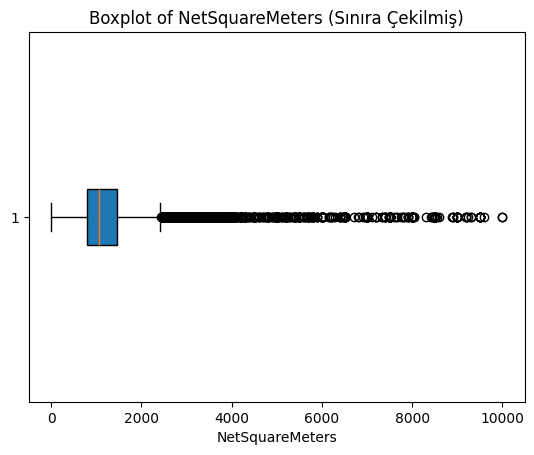

In [510]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
numeric_columns = [col for col in numeric_columns if col in df.columns]
# Aykırı değer analizi ve baskılama işlemi
def analyze_and_cap_outliers(df, numeric_columns):
    for col in numeric_columns:
        print(f"\n--- {col} Sütunu ---")

        # Boxplot ile aykırı değerleri görselleştir
        plt.boxplot(df[col], vert=False, patch_artist=True)
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.show()

        # IQR yöntemi ile aykırı değer analizi
        Q1 = df[col].quantile(0.01)
        Q3 = df[col].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        print(f"IQR: {IQR}, Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Aykırı Değer Sayısı: {len(outliers)}")

        # Z-Score yöntemi ile aykırı değer analizi
        z_scores = zscore(df[col])
        outliers_z = df[np.abs(z_scores) > 3]
        print(f"Z-Score ile Aykırı Değer Sayısı: {len(outliers_z)}")

        # Aykırı değerleri sınıra çek
        df[col] = df[col].apply(
            lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x
        )

        # Sınıra çekilmiş veriyi tekrar görselleştir
        plt.boxplot(df[col].dropna(), vert=False, patch_artist=True)
        plt.title(f"Boxplot of {col} (Sınıra Çekilmiş)")
        plt.xlabel(col)
        plt.show()

    return df

df = analyze_and_cap_outliers(df, numeric_columns)


In [511]:
df['BuildingAgeCategory'] = pd.cut(df['BuildingAge'],
                                   bins=[-1, 5, 20, 50, 100, 1000, float('inf')],
                                   labels=['0-5', '6-20', '21-50', '51-100', '100-1000', '1000+'])


In [512]:

df['IsInsideSite'] = df['InsideTheSite'].apply(lambda x: 1 if x == 'Evet' else 0)
df['price_per_room'] = df['price'] / df['NumberOfRooms']
df['age_density'] = df['BuildingAge'] / df['GrossSquareMeters']
df['room_density'] = df['NumberOfRooms'] / df['GrossSquareMeters']
df['price_per_sqm'] = df['price'] / df['GrossSquareMeters']
df['FloorDensity'] = df['NumberFloorsofBuilding'] / df['GrossSquareMeters']
df['AreaPerRoom'] = df['NetSquareMeters'] / df['NumberOfRooms']







In [513]:
df.columns = df.columns.str.lower()

In [514]:
display(df.head())

,district,price,grosssquaremeters,buildingage,numberfloorsofbuilding,usingstatus,eligibilityforinvestment,buildstatus,titlestatus,itemstatus,...,balcony,pricestatus,buildingagecategory,isinsidesite,price_per_room,age_density,room_density,price_per_sqm,floordensity,areaperroom
0,adalar,3100000.0,1602.0,21,3,Mülk Sahibi Oturuyor,Bilinmiyor,Bilinmiyor,Kat Mülkiyeti,Eşyalı,...,Yok,Genel Fiyat,21-50,0,1.000000e+05,0.013109,0.019351,1935.081149,0.001873,38.774194
1,adalar,1600000.0,1202.0,510,3,Mülk Sahibi Oturuyor,Yatırıma Uygun,İkinci El,Kat Mülkiyeti,Eşyalı,...,Var,Genel Fiyat,100-1000,0,7.619048e+04,0.424293,0.017471,1331.114809,0.002496,47.714286
2,adalar,18500000.0,3502.0,21,2,Mülk Sahibi Oturuyor,Bilinmiyor,Bilinmiyor,Kat Mülkiyeti,Boş,...,Yok,Genel Fiyat,21-50,0,5.967742e+05,0.005997,0.008852,5282.695603,0.000571,96.838710
3,adalar,9500000.0,5502.0,1115,3,Mülk Sahibi Oturuyor,Bilinmiyor,İkinci El,Kat Mülkiyeti,Boş,...,Yok,Genel Fiyat,1000+,0,1.187500e+06,0.202654,0.001454,1726.644856,0.000545,675.250000
4,adalar,25000000.0,8402.0,21,4,Boş,Bilinmiyor,İkinci El,Kat Mülkiyeti,Boş,...,Yok,Genel Fiyat,21-50,0,3.125000e+06,0.002499,0.000952,2975.482028,0.000476,875.250000


price                     1.000000
price_per_room            0.445265
price_per_sqm             0.328697
numberofbathrooms         0.245542
netsquaremeters           0.225218
grosssquaremeters         0.206476
floordensity              0.110957
numberofrooms             0.102254
room_density              0.094038
age_density               0.068021
areaperroom               0.060544
floorlocation             0.037293
buildingage               0.022032
isinsidesite              0.022017
numberfloorsofbuilding    0.013743
Name: price, dtype: float64


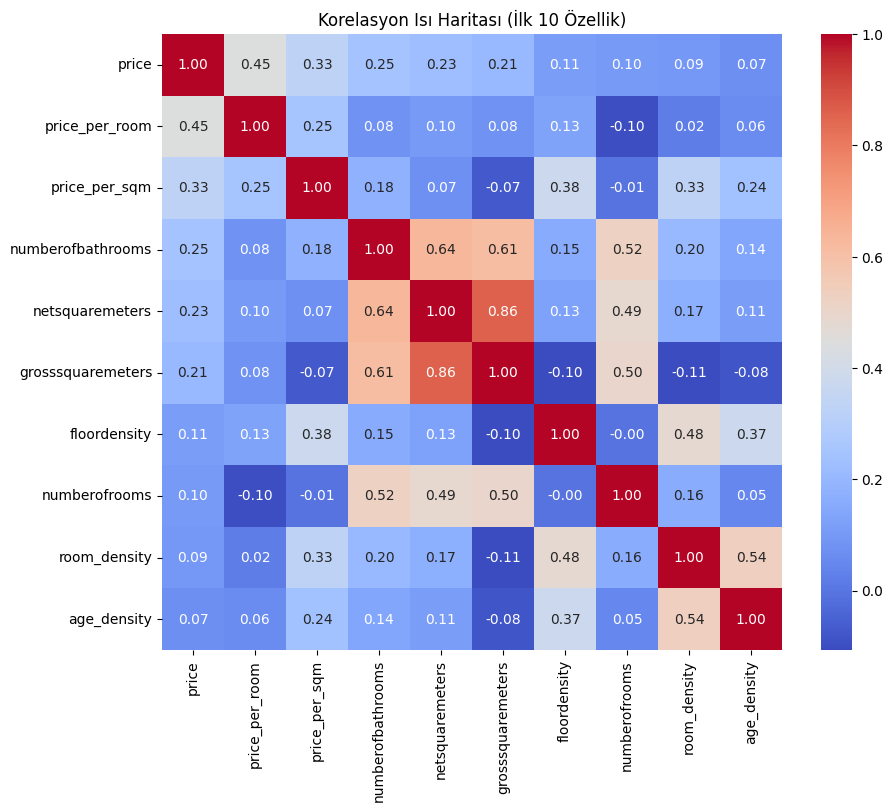

In [515]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece sayısal sütunları al
numeric_df = df.select_dtypes(include=['number'])

# Korelasyon matrisi
correlation_matrix = numeric_df.corr()

# Hedef değişkenin korelasyonları
target_corr = correlation_matrix['price'].sort_values(ascending=False)
print(target_corr)

# Korelasyon ısı haritası (sadece en çok ilgili ilk 10 değişken)
top_corr_features = target_corr.index[:10]  # İlk 10
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix.loc[top_corr_features, top_corr_features], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasyon Isı Haritası (İlk 10 Özellik)")
plt.show()


grosssquaremeters ve netsquaremeters çok korelasyonlu overfit e sebep olabilir çıkarmak istedm


In [516]:
df.drop(columns=['grosssquaremeters'], inplace=True)


ENCODING

In [539]:
# Kategorik (object veya category tipi) sütunları al
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Her sütun için benzersiz değerleri yazdır
for col in categorical_cols:
    print(f"\n🔹 {col} sütunu - Benzersiz Değerler:")
    print(df[col].unique())


In [517]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Label Encoding uygulanacak değişkenler
label_encoding_columns = [
    'usingstatus', 'crediteligibility', 'insidethesite', 'swap',
    'balcony', 'pricestatus', 'buildingagecategory']

label_encoder = LabelEncoder()
for col in label_encoding_columns:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col])

# One-Hot Encoding uygulanacak değişkenler
one_hot_encoding_columns = [
    'eligibilityforinvestment', 'buildstatus', 'titlestatus', 'heatingtype', 'structuretype', 'itemstatus'
]

df = pd.get_dummies(df, columns=one_hot_encoding_columns, drop_first=True)



In [518]:
df.head()

,district,price,buildingage,numberfloorsofbuilding,usingstatus,numberofbathrooms,netsquaremeters,numberofrooms,floorlocation,crediteligibility,...,heatingtype_Yerden Isıtma,structuretype_Betonarme,structuretype_Bilinmiyor,structuretype_Kagir,structuretype_Kütük,structuretype_Prefabrik,structuretype_Taş Bina,structuretype_Yığma,structuretype_Çelik,itemstatus_Eşyalı
0,adalar,3100000.0,21,3,2,2.0,1202.0,31.0,4.0,1,...,False,False,True,False,False,False,False,False,False,True
1,adalar,1600000.0,510,3,2,1.0,1002.0,21.0,4.0,1,...,False,True,False,False,False,False,False,False,False,True
2,adalar,18500000.0,21,2,2,3.0,3002.0,31.0,4.0,1,...,False,False,True,False,False,False,False,False,False,False
3,adalar,9500000.0,1115,3,2,4.0,5402.0,8.0,4.0,2,...,False,True,False,False,False,False,False,False,False,False
4,adalar,25000000.0,21,4,0,3.0,7002.0,8.0,4.0,1,...,False,False,False,False,False,False,False,False,False,False


In [519]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25155 entries, 0 to 25154
Data columns (total 54 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   district                                       25155 non-null  object 
 1   price                                          25155 non-null  float64
 2   buildingage                                    25155 non-null  int64  
 3   numberfloorsofbuilding                         25155 non-null  int64  
 4   usingstatus                                    25155 non-null  int64  
 5   numberofbathrooms                              25155 non-null  float64
 6   netsquaremeters                                25155 non-null  float64
 7   numberofrooms                                  25155 non-null  float64
 8   floorlocation                                  25155 non-null  float64
 9   crediteligibility                              251

burayı hakan hocamdan öğrendim teşekkür ederim districti ne yapacağımı bulamamıştım. ilçe bilgisi olduğu için çok önemli bir feature.

In [520]:
# District bazında price ortalamalarını hesaplama
district_price_mean = df.groupby('district')['price'].mean().sort_values()

# Sonuçları görüntüleme
print(district_price_mean)

district
esenyurt         1.144673e+06
sultangazi       2.227330e+06
sancaktepe       2.491049e+06
esenler          2.597054e+06
sultanbeyli      2.638486e+06
kucukcekmece     2.778400e+06
avcilar          2.798262e+06
tuzla            3.076197e+06
beylikduzu       3.489906e+06
bayrampasa       3.526098e+06
arnavutkoy       3.676636e+06
eyupsultan       3.757568e+06
bahcelievler     3.819172e+06
gaziosmanpasa    3.935275e+06
pendik           3.967046e+06
basaksehir       4.130960e+06
cekmekoy         4.354122e+06
kagithane        4.652585e+06
umraniye         5.015548e+06
gungoren         5.521146e+06
fatih            6.102682e+06
maltepe          6.200866e+06
atasehir         6.447886e+06
kartal           6.895636e+06
silivri          7.118183e+06
bagcilar         7.621348e+06
buyukcekmece     8.082448e+06
beyoglu          8.638329e+06
sile             1.216683e+07
sariyer          1.223825e+07
zeytinburnu      1.236886e+07
sisli            1.254573e+07
bakirkoy         1.259360e+07
k

district (ilçe) değişkeninin fiyat (price) üzerinde anlamlı bir etkisi var mı?
Bunu test ediyoruz.

ANOVA, birden fazla grup arasında ortalama farkı var mı diye test eder.



In [521]:
from scipy.stats import f_oneway

# ANOVA testi
anova_result = f_oneway(*(df[df['district'] == district]['price'] for district in df['district'].unique()))
display("ANOVA F-statistic:", anova_result.statistic)
display("ANOVA p-value:", anova_result.pvalue)

'ANOVA F-statistic:'

np.float64(33.59323129549422)

'ANOVA p-value:'

np.float64(8.535557874154429e-237)

In [522]:

# Hedefe dayalı kodlama
df['district_encoded'] = df['district'].map(district_price_mean)

# Orijinal district sütununu kaldırma
df = df.drop(columns=['district'])

# Sonuçları görüntüleme
display(df[['district_encoded', 'price']].head())


,district_encoded,price
0,1.924913e+07,3100000.0
1,1.924913e+07,1600000.0
2,1.924913e+07,18500000.0
3,1.924913e+07,9500000.0
4,1.924913e+07,25000000.0


In [523]:
# İlçeye göre fiyat yoğunluğu
district_price_mean = df.groupby('district_encoded')['price'].transform('mean')
df['district_price_density'] = df['price'] / district_price_mean

tekrar 5 veriyi çağırdım ki bakalım district nasıl olmuş

In [524]:
df.head()

,price,buildingage,numberfloorsofbuilding,usingstatus,numberofbathrooms,netsquaremeters,numberofrooms,floorlocation,crediteligibility,insidethesite,...,structuretype_Bilinmiyor,structuretype_Kagir,structuretype_Kütük,structuretype_Prefabrik,structuretype_Taş Bina,structuretype_Yığma,structuretype_Çelik,itemstatus_Eşyalı,district_encoded,district_price_density
0,3100000.0,21,3,2,2.0,1202.0,31.0,4.0,1,1,...,True,False,False,False,False,False,False,True,1.924913e+07,0.161046
1,1600000.0,510,3,2,1.0,1002.0,21.0,4.0,1,1,...,False,False,False,False,False,False,False,True,1.924913e+07,0.083121
2,18500000.0,21,2,2,3.0,3002.0,31.0,4.0,1,1,...,True,False,False,False,False,False,False,False,1.924913e+07,0.961082
3,9500000.0,1115,3,2,4.0,5402.0,8.0,4.0,2,1,...,False,False,False,False,False,False,False,False,1.924913e+07,0.493529
4,25000000.0,21,4,0,3.0,7002.0,8.0,4.0,1,1,...,False,False,False,False,False,False,False,False,1.924913e+07,1.298760


In [525]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25155 entries, 0 to 25154
Data columns (total 55 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   price                                          25155 non-null  float64
 1   buildingage                                    25155 non-null  int64  
 2   numberfloorsofbuilding                         25155 non-null  int64  
 3   usingstatus                                    25155 non-null  int64  
 4   numberofbathrooms                              25155 non-null  float64
 5   netsquaremeters                                25155 non-null  float64
 6   numberofrooms                                  25155 non-null  float64
 7   floorlocation                                  25155 non-null  float64
 8   crediteligibility                              25155 non-null  int64  
 9   insidethesite                                  251

kategorik sütunlar kalmamış mükemmel :D

In [526]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['price'])  # price hedef değişken
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [527]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(13169861573760.004))


MSE: 13169861573760.004
R²: 0.9854711786869212
RMSE: 3629030.390305378


decision tree r^2 0.98 çıktı. overfitting riski var ve mse RMSE çok yüksek.

In [528]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid=params, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("En iyi parametreler:", grid.best_params_)
print("En iyi R² skoru(ccross validationla):", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Yeni MSE:", mean_squared_error(y_test, y_pred_best))
print("Yeni R²:", r2_score(y_test, y_pred_best))


En iyi parametreler: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
En iyi R² skoru: 0.9384165962859198
Yeni MSE: 27918096628026.22
Yeni R²: 0.9692011161212186


grid search r^2 yi düşürdü ancak overfitting riski azalmış oldu. test verisine de uygulanmış hali 0.96. daha iyi bir model olabilir bu

bir de priceye log dönüşümü yapmak istedim


In [529]:
import numpy as np

# log(1 + price) ile yeni hedef sütun oluştur
df['log_price'] = np.log1p(df['price'])

# Özellikler ve hedefin kopyası
X_logged = df.drop(columns=['price', 'log_price'])  # sadece özellikler
y_logged = df['log_price']


In [530]:
from sklearn.model_selection import train_test_split

X_train_logged, X_test_logged, y_train_logged, y_test_logged = train_test_split(
    X_logged, y_logged, test_size=0.2, random_state=42)


In [543]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_logged = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_logged.fit(X_train_logged, y_train_logged)


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [544]:
from sklearn.metrics import mean_squared_error, r2_score

best_logged_model = grid_logged.best_estimator_
y_pred_logged = best_logged_model.predict(X_test_logged)

# Log scale değerlendirme
print("🔧 En iyi parametreler (log):", grid_logged.best_params_)
print("📉 MSE (log):", mean_squared_error(y_test_logged, y_pred_logged))
print("📈 R² (log):", r2_score(y_test_logged, y_pred_logged))
print("📊 En iyi CV R² skoru:", grid_logged.best_score_)



🔧 En iyi parametreler (log): {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2}
📉 MSE (log): 0.006064354110956774
📈 R² (log): 0.9960679604460339
📊 En iyi CV R² skoru: 0.9950579325130706


priceye log uygulanınca mse çok büyük oranda düştü. ve r^2 çok arttı

In [533]:
y_pred_real_logged = np.expm1(y_pred_logged)
y_test_real_logged = np.expm1(y_test_logged)

print("Gerçek MSE:", mean_squared_error(y_test_real_logged, y_pred_real_logged))
print("Gerçek R²:", r2_score(y_test_real_logged, y_pred_real_logged))


Gerçek MSE: 15638819103714.06
Gerçek R²: 0.982747456605153


exp ile log verisini geri dönüştürmek istedim

overfitting var mı diye bakmak için test verisine baktım

In [534]:
# Eğitim verisine tahmin
y_train_pred_logged = best_logged_model.predict(X_train_logged)
print("Train R² (log):", r2_score(y_train_logged, y_train_pred_logged))


Train R² (log): 0.9995405710888257


**RANDOM FOREST İLE İNCELEyeLİM**

In [535]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Grid parametreleri
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV ile model eğitimi
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_logged, y_train_logged)

# En iyi model ve tahminler
best_rf = rf_grid.best_estimator_
y_pred_rf_logged = best_rf.predict(X_test_logged)

# Log düzeyinde skorlar
print("🔧 En iyi RF parametreler:", rf_grid.best_params_)
print("📉 RF MSE (log):", mean_squared_error(y_test_logged, y_pred_rf_logged))
print("📈 RF R² (log):", r2_score(y_test_logged, y_pred_rf_logged))

# Gerçek değerlere dönüştür
y_pred_rf_real = np.expm1(y_pred_rf_logged)
y_test_rf_real = np.expm1(y_test_logged)

print("📉 RF MSE (gerçek):", mean_squared_error(y_test_rf_real, y_pred_rf_real))
print("📈 RF R² (gerçek):", r2_score(y_test_rf_real, y_pred_rf_real))

print("📊 En iyi CV R² skoru:", rf_grid.best_score_)  # ✅ CV sonucunu verir



Fitting 5 folds for each of 24 candidates, totalling 120 fits
🔧 En iyi RF parametreler: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
📉 RF MSE (log): 0.002454289356459468
📈 RF R² (log): 0.9984086742545194
📉 RF MSE (gerçek): 9953548264528.482
📈 RF R² (gerçek): 0.9890193740187391


In [542]:
print("📊 En iyi CrossValidation R² skoru:", rf_grid.best_score_)  # ✅ CV sonucunu verir

📊 En iyi CrossValidation R² skoru: 0.9974243414739506


logaritmik veriye random forest uyguladım. sonuçlar inanılmaz :D

In [536]:
# Eğitim verisine tahmin yap
y_train_rf_pred_logged = best_rf.predict(X_train_logged)

# Eğitimdeki R² ve MSE (log domain)
from sklearn.metrics import r2_score, mean_squared_error

print("🏋️‍♂️ Train R² (log):", r2_score(y_train_logged, y_train_rf_pred_logged))
print("🏋️‍♂️ Train MSE (log):", mean_squared_error(y_train_logged, y_train_rf_pred_logged))


🏋️‍♂️ Train R² (log): 0.9996950857155494
🏋️‍♂️ Train MSE (log): 0.000447582342497889


train verisine tahmin yaptım


In [537]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_logged, y_logged, cv=5, scoring='r2')
print("CV ortalama skor:", np.mean(cv_scores))


CV ortalama skor: 0.9922860967160683


In [538]:
import pandas as pd

importances = best_rf.feature_importances_
importance_df = pd.DataFrame({'feature': X_logged.columns, 'importance': importances})
print(importance_df.sort_values(by='importance', ascending=False))


                                          feature    importance
14                                 price_per_room  6.955877e-01
17                                  price_per_sqm  1.698042e-01
5                                   numberofrooms  6.166899e-02
4                                 netsquaremeters  4.001296e-02
53                         district_price_density  2.793726e-02
52                               district_encoded  2.799552e-03
18                                   floordensity  6.301193e-04
19                                    areaperroom  3.796049e-04
16                                   room_density  2.480602e-04
15                                    age_density  1.677790e-04
1                          numberfloorsofbuilding  1.355065e-04
3                               numberofbathrooms  1.196394e-04
6                                   floorlocation  5.406263e-05
12                            buildingagecategory  4.522572e-05
0                                     bu

burada featurelerimizin önem sıralaması var

sonuç olarak daha dengeli olan randomsearch(biraz uzun sürse de(40 dakika) en iyi sonucu verdi. overfittingi de train ve test verilerinin ikisi karşılaştırıp ve cross-validation yapıp overfitting riskinin az olduğunu görüntüledik. ayrıca logaritmik dönüşüm mse değerini çok azaltıyor.